<h2> Understanding DICOM data - Loading, Attributes and Visualization</h2>

<h3> 1. Loading the data </h3> 
Function to load the dataset and collect it in series of useful, "readable" data:

In [3]:
from pathlib import Path
import collections
import os
import pydicom

def is_dicom(path: Path) -> bool:
    # fast sniff: "DICM" at byte offset 128 (common but not guaranteed)
    try:
        with open(path, "rb") as fp:
            fp.seek(128)
            return fp.read(4) == b"DICM"
    except OSError:
        return False

def find_dicom_series(root_or_files):
    """
    Accept either:
      - a folder path (walk recursively), OR
      - an iterable of file paths
    Return: dict[SeriesInstanceUID] -> list[Path]
    """
    series = collections.defaultdict(list)

    if isinstance(root_or_files, (str, os.PathLike, Path)):
        root = Path(root_or_files)
        it = (p for p in root.rglob("*") if p.is_file())
    else:
        it = (Path(p) for p in root_or_files)

    for f in it:
        if not f.is_file():
            continue
        if not is_dicom(f):
            continue

        try:
            ds = pydicom.dcmread(f, stop_before_pixels=True, force=True) # only read metadata, ignore image data for now
        except Exception:
            continue

        uid = ds.get("SeriesInstanceUID") or ds.get("SOPInstanceUID")
        series[str(uid)].append(f)

    return series

In [ ]:
file_path = r'dicom_files_path'
series = find_dicom_series(file_path) #select the dataset here
for uid, files in series.items():
        # read metadata from the first file of this series
        ds = pydicom.dcmread(files[0], stop_before_pixels=True, force=True)                
        #Some metadata displayed
        print(f"Series UID: {uid}")
        print(f"Study Instance UID: {getattr(ds, 'StudyInstanceUID', 'N/A')}")
        print(f"Number of files: {len(files)}")
        print(f"Modality: {getattr(ds, 'Modality', 'N/A')}")
        print(f"Series Description: {getattr(ds, 'SeriesDescription', 'N/A')}")
        print("---")


Series UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000009
Study Instance UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000006
Number of files: 148
Modality: CT
Series Description: AC   CT Brain  3.0  Hf38
---
Series UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000613
Study Instance UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000310
Number of files: 148
Modality: PT
Series Description: PET Brain uncorrected
---
Series UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000160
Study Instance UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000006
Number of files: 148
Modality: PT
Series Description: PET Brain uncorrected
---
Series UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000313
Study Instance UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000310
Number of files: 148
Modality: CT
Series Description: AC   CT Brain  3.0  Hf38
---
Series UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000463
Study Instan

Each series contains 148 files, and each file is a different slice of the brain, taken upon patient imaging. 

Next step is to separate the series per patient, based on their unique Study instance value:

In [5]:
def group_series_by_patient(series_dict):
    """
    series_dict : {SeriesUID: [filepaths]}
    returns     : {PatientKey: {StudyUID: [SeriesUID, ...]}}
    """
    patients = collections.defaultdict(lambda: collections.defaultdict(list))

    for series_uid, files in series_dict.items():
        if not files:
            print(f"[WARNING] No files for series {series_uid}, skipping.")
            continue

        try:
            ds = pydicom.dcmread(files[0], stop_before_pixels=True, force=True)
        except Exception as e:
            print(f"[WARNING] Could not read {files[0]}: {e}")
            continue

        def safe_get(tag):
            val = getattr(ds, tag, None)
            return val if val not in (None, "", " ") else None

        # Stable patient key, robust to anonymisation
        date  = getattr(ds, "StudyDate", "NODATE")
        time  = getattr(ds, "StudyTime", "000000")[:6]
        patient_key = (
            safe_get("PatientID") or #usually empty due to anonymisation
            safe_get("StudyInstanceUID") or # this one is the key one 
            f"{date}_{time}"
        )
        
        study_uid = safe_get("StudyInstanceUID")
        if study_uid is None:
            print(f"[WARNING] Missing StudyInstanceUID for series {series_uid}, skipping.")
            continue

        patients[patient_key][study_uid].append(series_uid)

    return patients


Execution Group Series per patient: 

In [6]:
patients = group_series_by_patient(series)
print(f"Found {len(patients)} patients")

Found 125 patients


<h3> 2. DICOM Attributes </h3>

It is important to first understand all the attributes that a DICOM dataset consists of. Therefore, a list of all tags per imaging process is provided:

In [7]:
patient_key = list(patients.keys())[0]
studies = patients[patient_key]
study_uid = list(studies.keys())[0]
series_uids = studies[study_uid]
series_uid = series_uids[0]
file_path = series[series_uid][0]
ds = pydicom.dcmread(file_path, stop_before_pixels=True, force=True)
for elem in ds:
    print(elem)

(0008,0005) Specific Character Set              CS: 'ISO_IR 192'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'CT_SOM5 SPI']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000072
(0008,0020) Study Date                          DA: '20250220'
(0008,0021) Series Date                         DA: '20250220'
(0008,0022) Acquisition Date                    DA: '20250220'
(0008,0023) Content Date                        DA: '20250220'
(0008,002A) Acquisition DateTime                DT: '20250220144618.626000'
(0008,0030) Study Time                          TM: '143953.971000'
(0008,0031) Series Time                         TM: '144627.853000'
(0008,0032) Acquisition Time                    TM: '144618.626000'
(0008,0033) Content Time                        TM: '144618.626000'
(0008,0050) Accession Number                    SH: 'F01

Group the files per patient. Structural display of the metadata:

In [8]:
patients = group_series_by_patient(series)
print(f"Found {len(patients)} patients")

print(f"{'Serie count:':>14} | {'Type':<3} | {'Series Description':<35} | Slices | Dimension")
for pat_nr, (patient_key, studies) in enumerate(patients.items(), start=1):
    print(f"Patient {pat_nr}:    (PatientID: {patient_key})")
    for modality, study_des in studies.items():
        for ser_idx, series_uid in enumerate(study_des, start=1):
            ds = pydicom.dcmread(series[series_uid][0], stop_before_pixels=True, force=True)

            mod = getattr(ds, "Modality", "")
            ser = getattr(ds, "SeriesDescription", "")
            stu = getattr(ds, "StudyDescription", "")
            slices_nr = len(series[series_uid])
            rows = int(getattr(ds, "Rows", -1))
            cols = int(getattr(ds, "Columns", -1))

            print(f"     {ser_idx:>8}. |  {mod:<4}| {ser:<35} |  {slices_nr}   | {rows} x {cols} ")

Found 125 patients
  Serie count: | Type | Series Description                  | Slices | Dimension
Patient 1:    (PatientID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000006)
            1. |  CT  | AC   CT Brain  3.0  Hf38            |  148   | 512 x 512 
            2. |  PT  | PET Brain uncorrected               |  148   | 400 x 400 
Patient 2:    (PatientID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000310)
            1. |  PT  | PET Brain uncorrected               |  148   | 400 x 400 
            2. |  CT  | AC   CT Brain  3.0  Hf38            |  148   | 512 x 512 
            3. |  PT  | PET Brain                           |  148   | 400 x 400 
Patient 3:    (PatientID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000762)
            1. |  CT  | AC   CT Brain  3.0  Hf38            |  148   | 512 x 512 
            2. |  PT  | PET Brain                           |  148   | 400 x 400 
            3. |  PT  | PET Brain uncorrected               |  148   | 

<h3>3. Vizualization - working with images </h3>

Once the attributes are known, better work with visualization is available. To begin with, data needs to be sorted - volumes based on their z-axis tag are being stacked vertically per patient (slices).

In [9]:
import numpy as np

def sort_instances(files):
    """Sort DICOM instance files into slice order. Returns list of pydicom datasets."""
    dsets = []
    for f in files:
        try:
            ds = pydicom.dcmread(f, force=True)
            dsets.append(ds)
        except Exception:
            continue

    def z_key(ds):
        ipp = getattr(ds, "ImagePositionPatient", None)  
        if ipp is not None and len(ipp) == 3:
            return float(ipp[2])
        return float(getattr(ds, "InstanceNumber", 0))

    dsets.sort(key=z_key)
    return dsets

def load_volume_from_series(files, apply_rescale=True):
    """Load a DICOM series into a 3D numpy array (Z, Y, X)."""
    dsets = sort_instances(files) # get sorted pydicom datasets for this series on the axis of acquisition (Z) 
    if not dsets:
        raise ValueError("No readable DICOM instances in this series.")

    vol = []
    for ds in dsets:
        arr = ds.pixel_array.astype(np.float32)

        if apply_rescale:
            slope = float(getattr(ds, "RescaleSlope", 1.0))
            inter = float(getattr(ds, "RescaleIntercept", 0.0))
            arr = arr * slope + inter

        vol.append(arr)

    vol = np.stack(vol, axis=0)  # (Z, Y, X) classical
    return vol, dsets[0]         # return first ds for metadata

In [10]:
# Check series if it works, and 
series_uids = list(series.keys())
idx = 148*2 # pick index you want:
series_uid = series_uids[idx]
files = series[series_uid]
loaded_series = load_volume_from_series(files) # this will load the whole volume into memory, be careful with large series!
print("Loaded series shape (Z, Y, X):", loaded_series[0].shape)
print("Loaded series UID:", loaded_series[1].SeriesInstanceUID)
print("Modality:", loaded_series[1].get("Modality", ""))
print("Series description:", loaded_series[1].get("SeriesDescription", ""))

Loaded series shape (Z, Y, X): (148, 400, 400)
Loaded series UID: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100044609
Modality: PT
Series description: PET Brain uncorrected


Next step is separating different modalities under the same patient between three different modalities: 
* CT
* PET Uncorrected
* PET 

In [11]:
def series_per_patient(patients_sorted, series_dict, patient_key):
    """
    Returns dict with keys: 'CT', 'PET_uncorrected', 'PET'
    Values are series_uids, attributes read from their modality
    """
    ct_uid = None
    pet_u = None
    pet_c = None

    studies = patients_sorted[patient_key]
    # iterate studies in order
    for study_uid, series_uids in studies.items():
        for suid in series_uids:
            files = series_dict.get(suid, [])
            if not files:
                continue

            ds = pydicom.dcmread(files[0], stop_before_pixels=True, force=True)
            mod = getattr(ds, "Modality", "")
            desc = getattr(ds, "SeriesDescription", "") 
            rows = int(getattr(ds, "Rows", -1))
            cols = int(getattr(ds, "Columns", -1))

            if mod == "CT" and ct_uid is None:
                ct_uid = suid

            if mod == "PT":
                if "uncorrected" in desc.lower():
                    if pet_u is None:
                        pet_u = suid
                else:
                    if pet_c is None:
                        pet_c = suid


    return {"CT": ct_uid, "PET_uncorrected": pet_u, "PET": pet_c}

In [12]:
# Check the function for one patient, print the modality and series uids for each type of series (CT, PET uncorrected, PET corrected)
patient_keys = list(patients.keys())
idx = 1 # pick patient index you want
one_patient_key = patient_keys[idx]
picked_series = series_per_patient(patients, series, one_patient_key)
print(f"Picked series for patient {idx+1}: UID {one_patient_key}:")
for key, suid in picked_series.items():
    print(f"  {key}: {suid} ")


Picked series for patient 2: UID 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000310:
  CT: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000313 
  PET_uncorrected: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000613 
  PET: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000463 


Final Vizualization Code - sort the series per patient, and once they are sorted, display the slices of the selected modalities, using the above functions. Additionally, select slice and patient option is available, allowing the user to navigate easily towards slices (moving upwards/downwards) and compare the results of the different imaging technologies used in one imaging.

In [20]:
import matplotlib.pyplot as plt

def show_one_patient(patient_key, patients_sorted, series_dict, series_files_dict, slice_index=None, patient_label=None):
    picked = series_per_patient(patients_sorted, series_files_dict, patient_key)

    if picked["CT"] is None and picked["PET_uncorrected"] is None and picked["PET"] is None:
        raise ValueError("No CT/PET series found for this patient.")

    vols = {}
    metas = {}

    # Load volumes (CT rescale to HU is useful; PET rescale may also be useful)
    if picked["CT"]:
        vols["CT"], metas["CT"] = load_volume_from_series(series_files_dict[picked["CT"]], apply_rescale=True)
    if picked["PET_uncorrected"]:
        vols["PET uncorrected"], metas["PET uncorrected"] = load_volume_from_series(series_files_dict[picked["PET_uncorrected"]], apply_rescale=True)
    if picked["PET"]:
        vols["PET"], metas["PET"] = load_volume_from_series(series_files_dict[picked["PET"]], apply_rescale=True)

    # choose slice index = middle slice (based on CT if exists, else first available)
    ref_key = "CT" if "CT" in vols else next(iter(vols.keys()))
    z = vols[ref_key].shape[0]
    if slice_index is None:
        slice_index = z // 2
    slice_index = max(0, min(slice_index, z - 1))

    # plot
    keys_in_order = ["CT", "PET uncorrected", "PET"]
    present = [k for k in keys_in_order if k in vols]

    fig, axes = plt.subplots(1, len(present), figsize=(5 * len(present), 5))
    if len(present) == 1:
        axes = [axes]

    for ax, k in zip(axes, present):
        img = vols[k][slice_index]

        # simple display defaults:
        if k == "CT":
            # typical brain-ish window (you can change)
            ax.imshow(img, cmap="gray", vmin=-300, vmax=300)
        else:
            ax.imshow(img, cmap="gray")

        ds0 = metas[k]
        desc = getattr(ds0, "SeriesDescription", "")
        ax.set_title(f"{k}\n{desc}".strip())
        title = patient_label if patient_label is not None else patient_key

    plt.suptitle(f"{title}   |   slice {slice_index}", y=1.07, fontsize=16) 
    plt.tight_layout()
    plt.show()

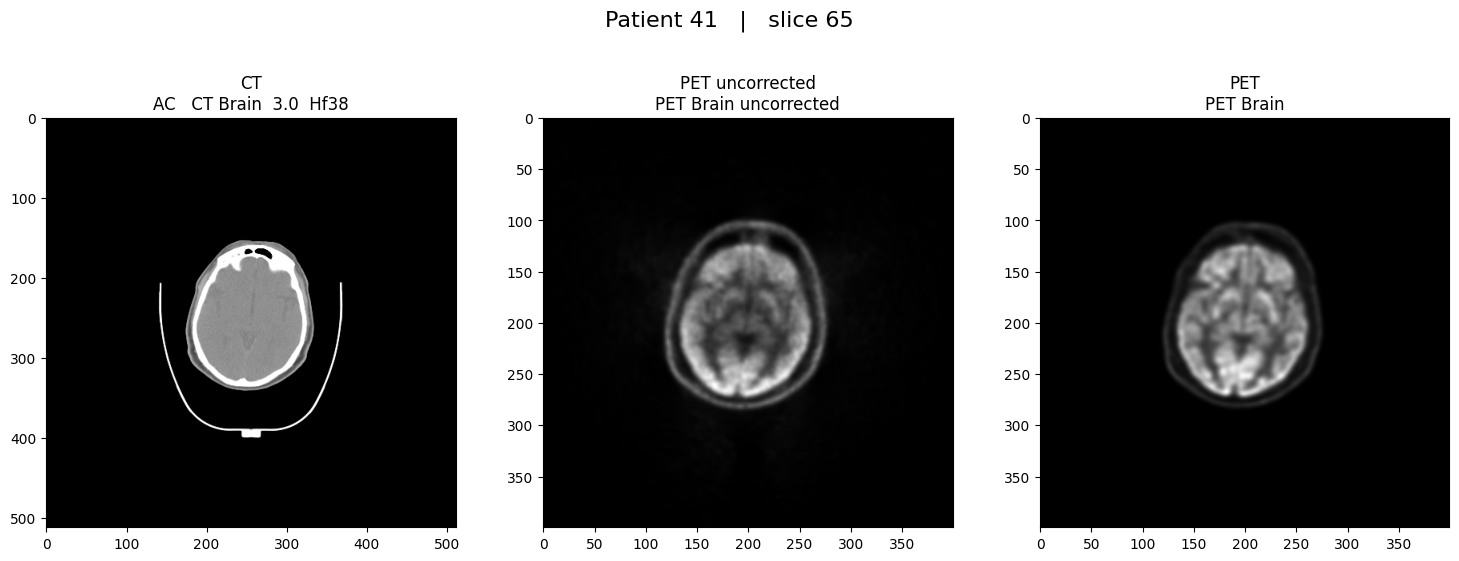

In [21]:
patient_keys = list(patients.keys()) # sorted list of patient keys for indexing

#Choose a patient index
idx = 40
one_patient_key = patient_keys[idx] 

#Choose a slice index 
slc_idx = 65

show_one_patient(
    patient_key=one_patient_key,
    patients_sorted=patients,
    series_dict=None,               # not used in this version
    series_files_dict=series,       # your {series_uid: [files]}
    slice_index=slc_idx,
    patient_label =f"Patient {idx+1}"             # middle slice
)

Display series of brain scans, moving upwards: 

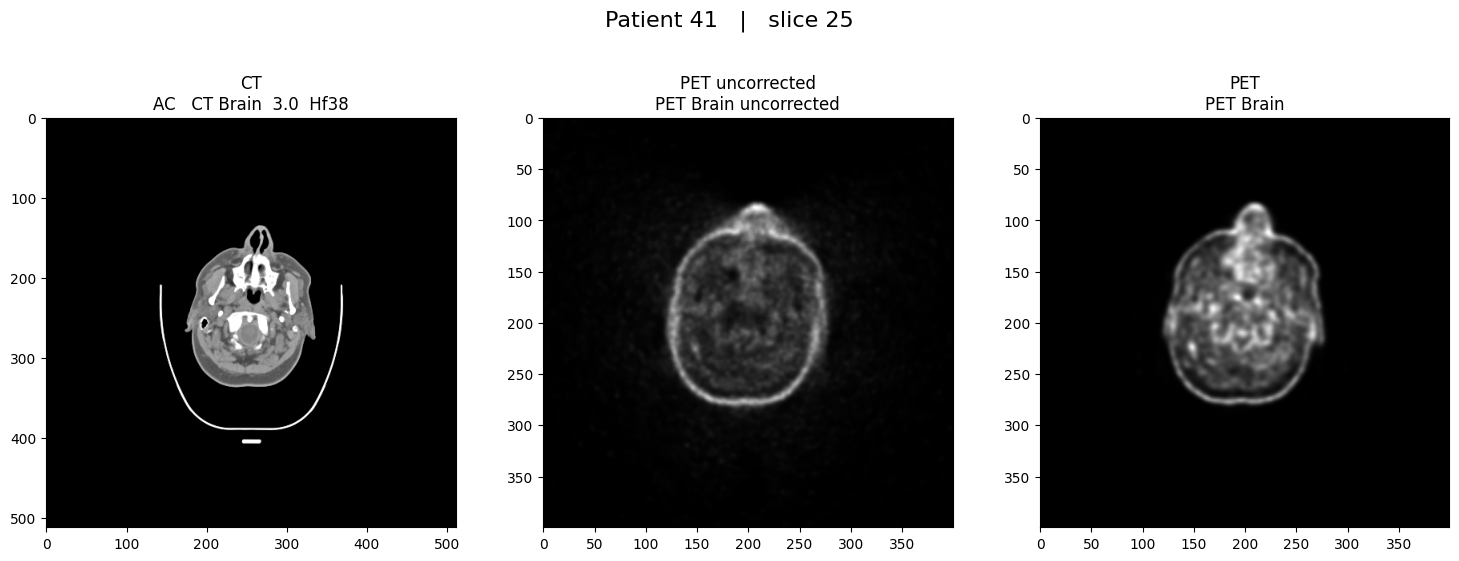

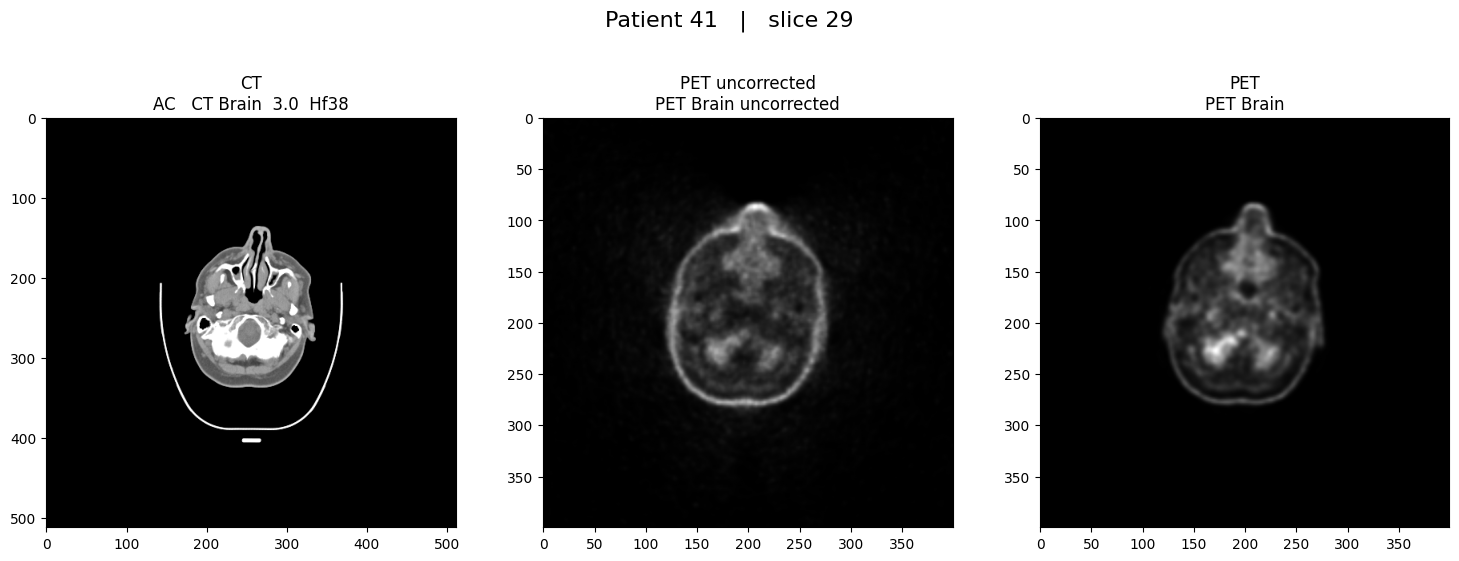

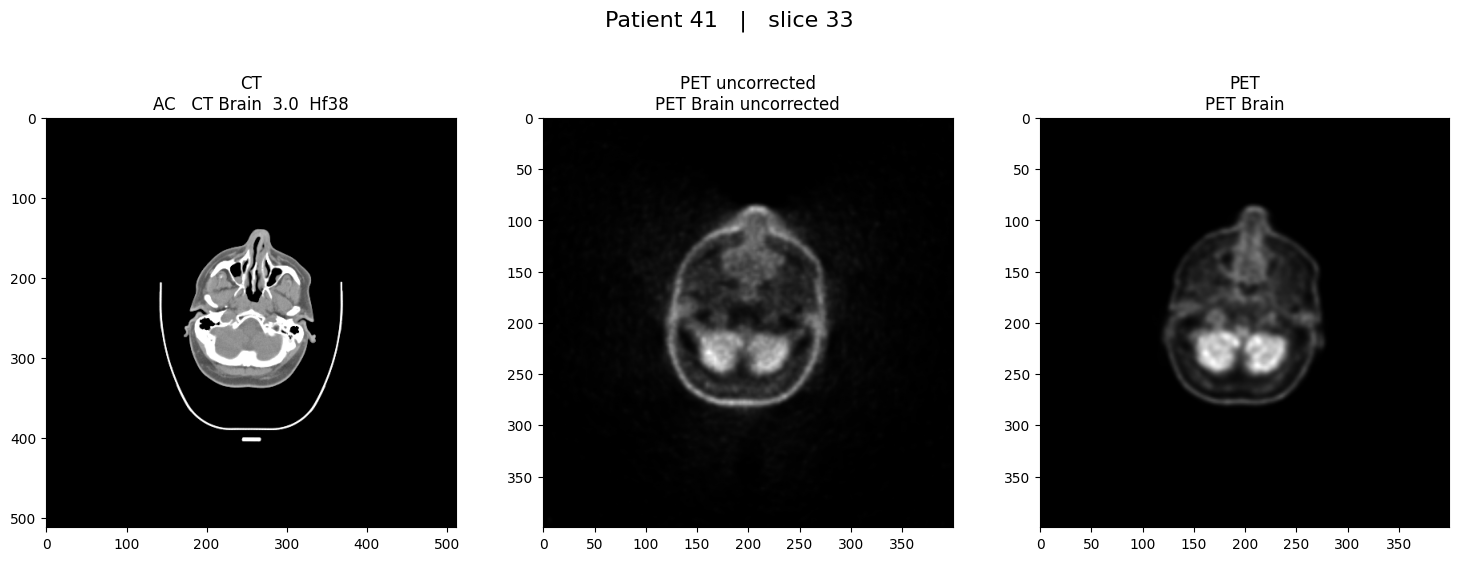

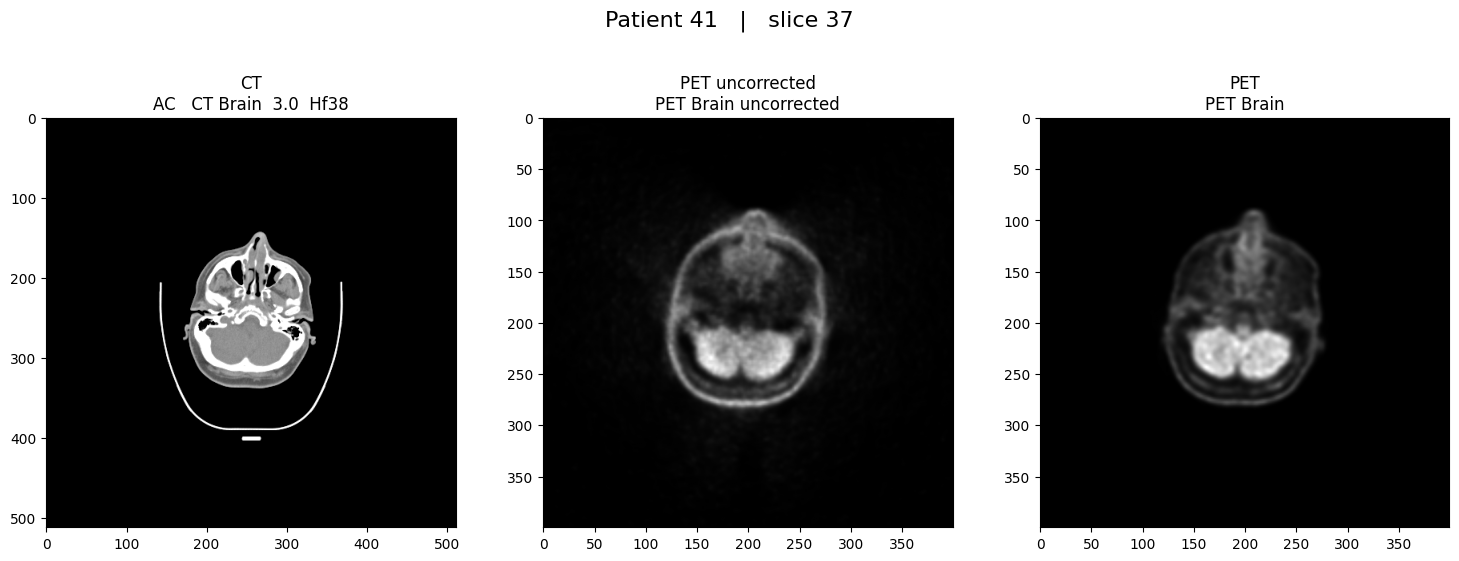

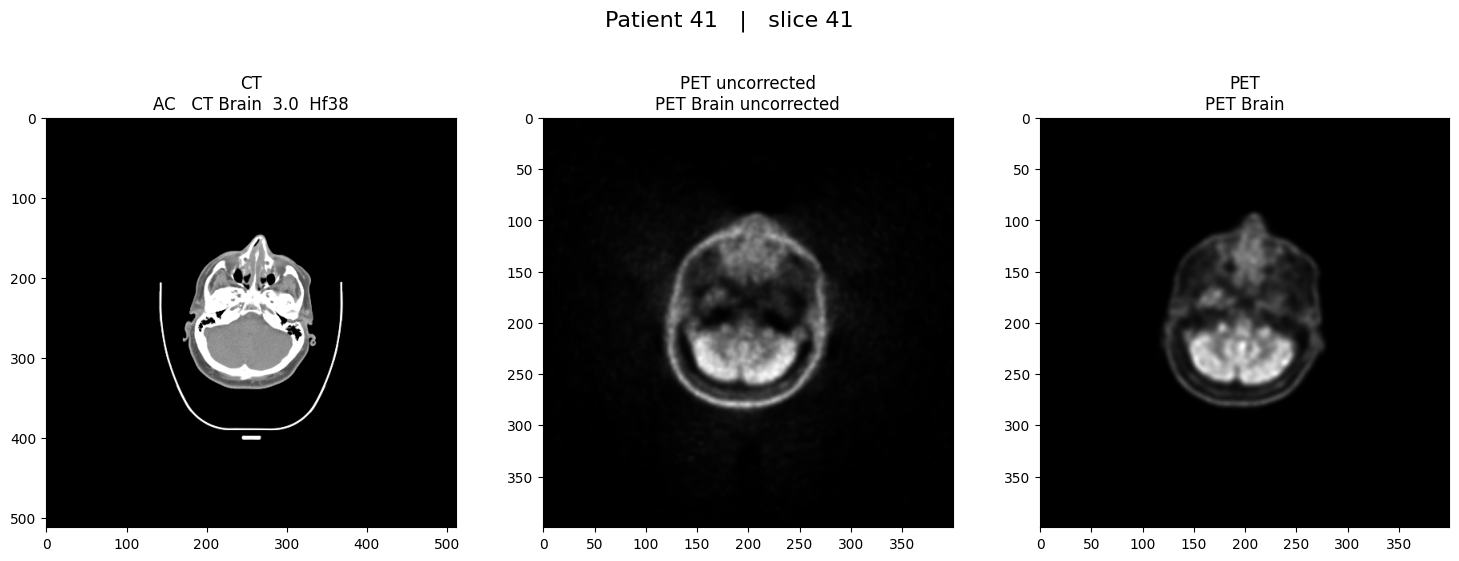

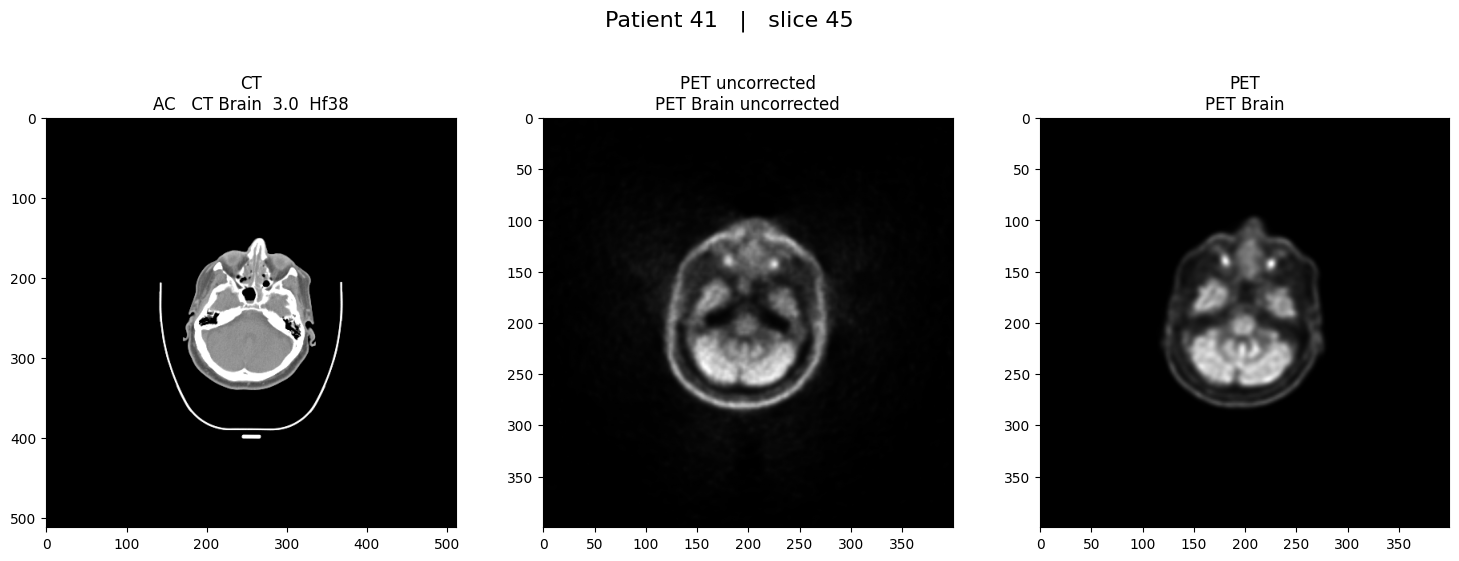

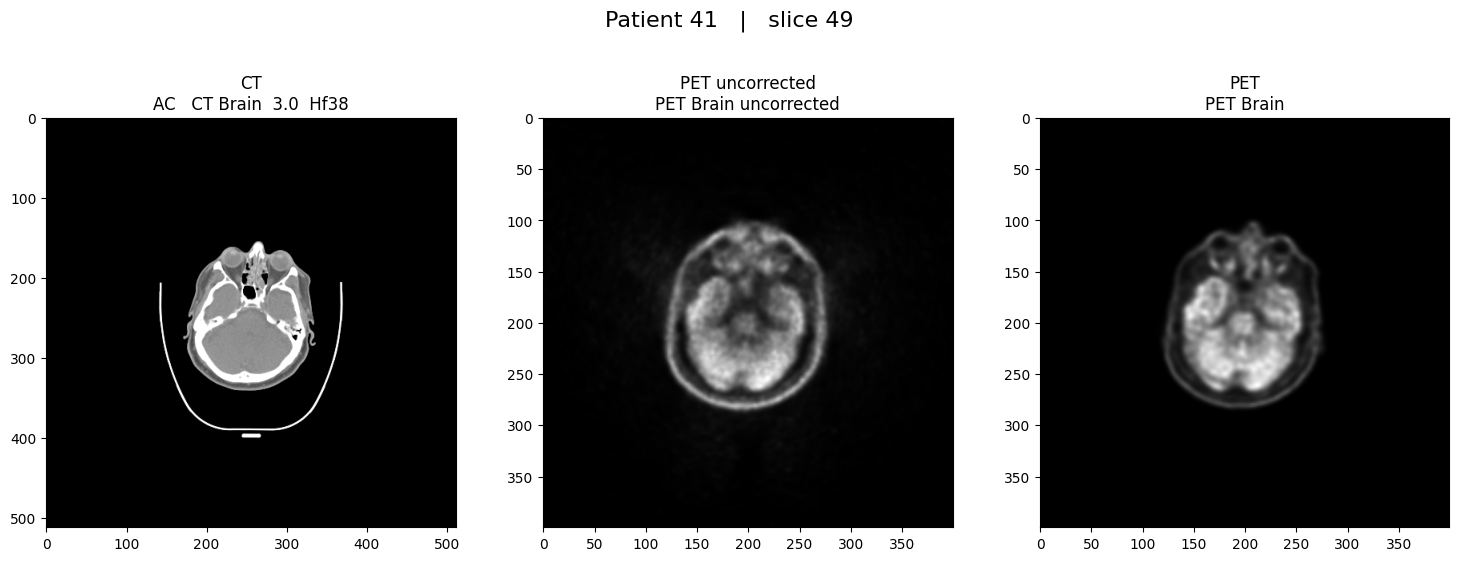

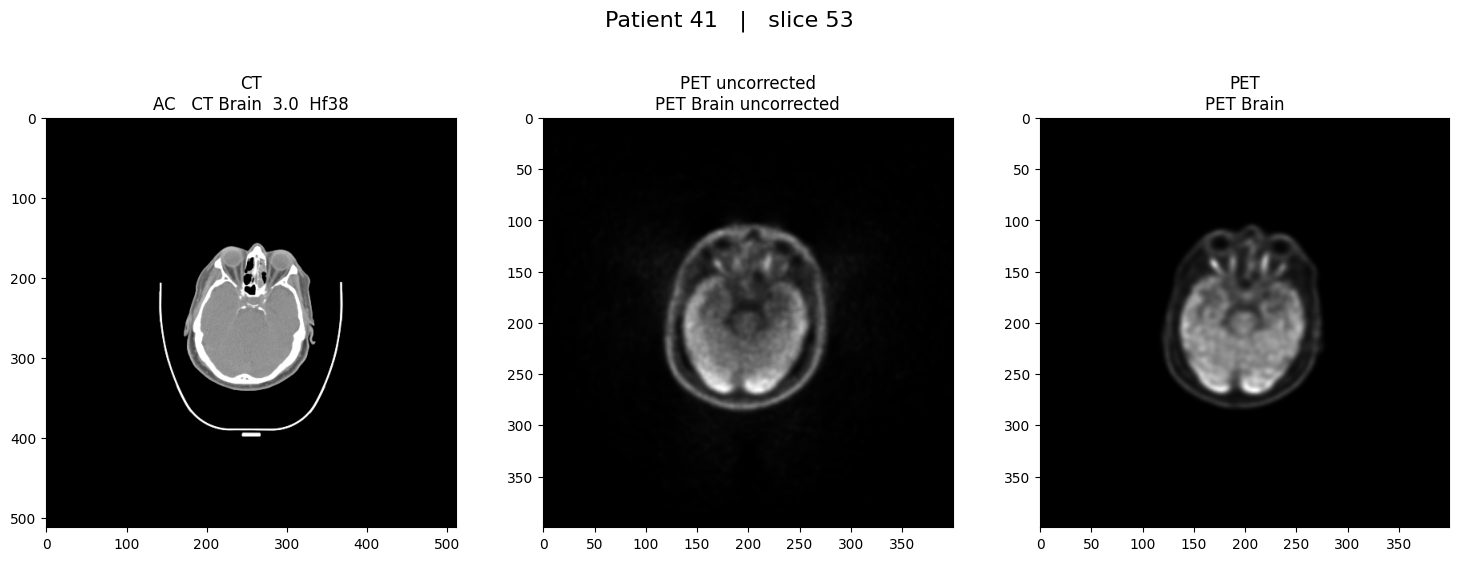

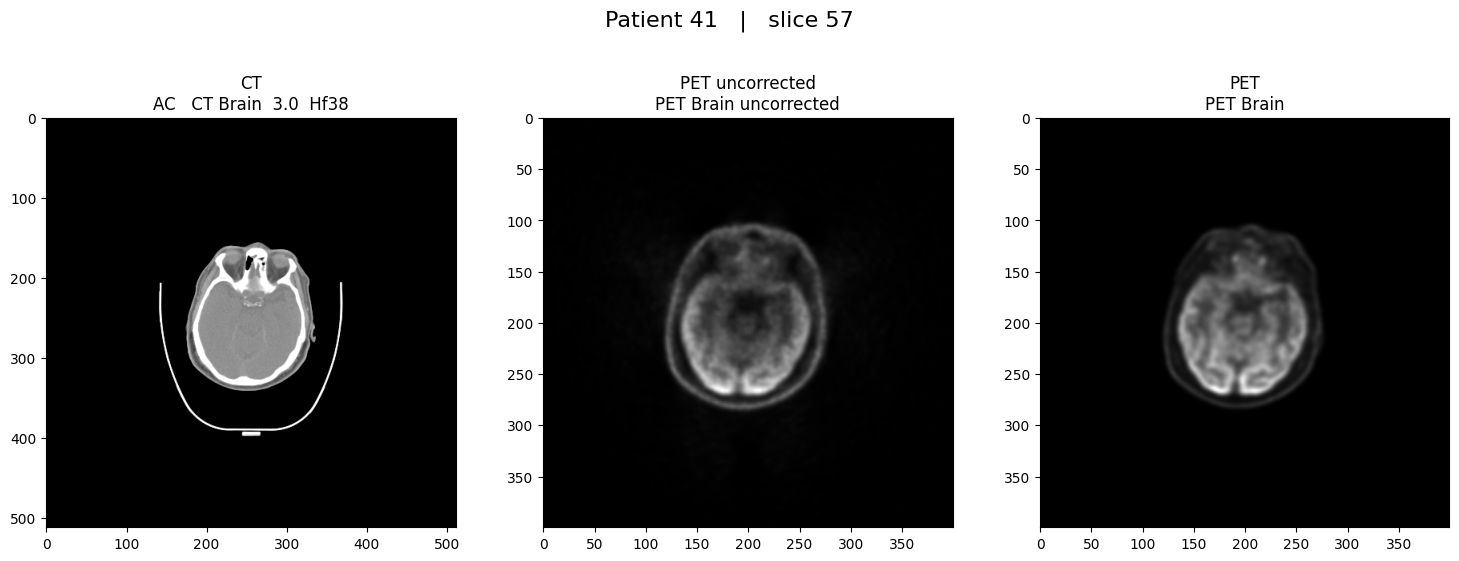

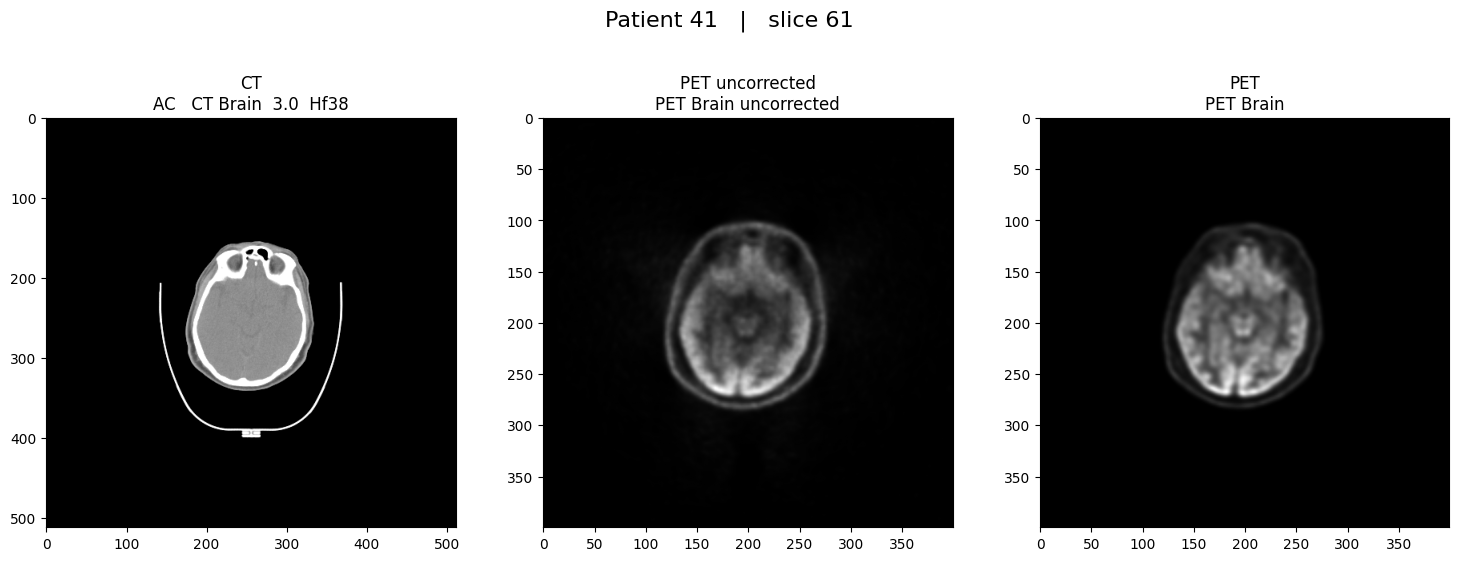

In [22]:
for slc in range(slc_idx-40,slc_idx, 4):
    show_one_patient(
        patient_key=one_patient_key,
        patients_sorted=patients,
        series_dict=None,               
        series_files_dict=series,       
        slice_index=slc,
        patient_label =f"Patient {idx+1}"             
    )

<h3>4. Multiplanar Vizualization </h3>

The volume data is 3D (CT and/or PET), so unlike selecting the slices by index manually, the single best slice index along each of the three anatomical axes (z=axial, y=coronal, x=sagittal) is selected. The goal is to land on a slice that shows the most meaningful anatomy, not padding or empty background, to display in a multiplanar view. 

In [ ]:
def best_index_by_foreground_area(vol, axis, modality="CT",
                                  ct_window=(-300, 300),
                                  ct_thr=0,
                                  pet_percentile=85):
    ''' Scores every slice along each axis by foreground segment - tissue instead of background/air.
        Returns the index of the slice with the largest foreground area, and the scores for all slices. 
    '''
    scores = np.zeros(vol.shape[axis], dtype=np.float64)
    n = vol.shape[axis]                      # number of slices along the given axis
    margin = int(n * 0.20)                   # removes 20% of slices from each end to avoid edge padding
    search_range = range(margin, n - margin) # focus on central slices

    for i in search_range:
        sl = np.take(vol, i, axis=axis)
        if modality.upper() == "CT":
            slw = np.clip(sl, ct_window[0], ct_window[1])
            mask = slw > ct_thr
        else:
            thr = np.percentile(sl, pet_percentile)
            mask = sl > thr
        scores[i] = mask.sum()

    return int(np.argmax(scores)), scores


def map_index(i_from, n_from, n_to):
    "Map an index from one length to another by relative position."
    if n_from <= 1 or n_to <= 1:
        return 0
    frac = i_from / (n_from - 1)
    return int(np.clip(round(frac * (n_to - 1)), 0, n_to - 1))


def pick_best_multiplanar_indices(vol_ct=None, vol_pet=None, prefer="CT"):
    """
    Picks per modality independently:
    - CT is commonly 512 × 512 × N
    - PET is commonly 128 × 128 × M or 192 × 192 × M

    A raw index of 200 in CT space does not mean the same anatomical location as
    index 200 in PET space. This function translates between them by fractional
    position, not absolute value.
    """
    if vol_ct is None and vol_pet is None:
        raise ValueError("Need at least one volume (CT or PET).")

    # Decide reference space
    if prefer.upper() == "CT" and vol_ct is not None:
        ref = "CT"
    elif vol_pet is not None:
        ref = "PET"
    else:
        ref = "CT"

    def pick_for(vol, modality):
        z, _ = best_index_by_foreground_area(vol, 0, modality=modality)
        y, _ = best_index_by_foreground_area(vol, 1, modality=modality)
        x, _ = best_index_by_foreground_area(vol, 2, modality=modality)
        return z, y, x

    idx_ct = pick_for(vol_ct, "CT") if vol_ct is not None else None
    idx_pet = pick_for(vol_pet, "PET") if vol_pet is not None else None

    # If only one modality exists, return it (in its own index space)
    if idx_ct is None:
        return idx_pet
    if idx_pet is None:
        return idx_ct

    # Both exist: combine in reference index space
    if ref == "CT":
        # map PET indices into CT space, then combine (average, or just use CT)
        pet_in_ct = (
            map_index(idx_pet[0], vol_pet.shape[0], vol_ct.shape[0]),
            map_index(idx_pet[1], vol_pet.shape[1], vol_ct.shape[1]),
            map_index(idx_pet[2], vol_pet.shape[2], vol_ct.shape[2]),
        )
        # average tends to be stable; you can also just return idx_ct
        combined = tuple(int(round((a + b) / 2)) for a, b in zip(idx_ct, pet_in_ct))
        return combined

    else:  
        ct_in_pet = (
            map_index(idx_ct[0], vol_ct.shape[0], vol_pet.shape[0]),
            map_index(idx_ct[1], vol_ct.shape[1], vol_pet.shape[1]),
            map_index(idx_ct[2], vol_ct.shape[2], vol_pet.shape[2]),
        )
        combined = tuple(int(round((a + b) / 2)) for a, b in zip(idx_pet, ct_in_pet))
        return combined

In [ ]:
def show_one_patient_multiplanar(patient_key, patients_sorted, series_dict, series_files_dict,
                                 z_idx=None, y_idx=None, x_idx=None, patient_label=None):
    picked = series_per_patient(patients_sorted, series_files_dict, patient_key)

    if picked["CT"] is None and picked["PET_uncorrected"] is None and picked["PET"] is None:
        raise ValueError("No CT/PET series found for this patient.")

    vols, metas = {}, {}

    if picked["CT"]:
        vols["CT"], metas["CT"] = load_volume_from_series(series_files_dict[picked["CT"]], apply_rescale=True)
    if picked["PET_uncorrected"]:
        vols["PET uncorrected"], metas["PET uncorrected"] = load_volume_from_series(series_files_dict[picked["PET_uncorrected"]], apply_rescale=True)
    if picked["PET"]:
        vols["PET"], metas["PET"] = load_volume_from_series(series_files_dict[picked["PET"]], apply_rescale=True)

    
    def pick_for(vol, modality):
        "Index picking logic for each volume and modality (independent, for display purposes)"
        z, _ = best_index_by_foreground_area(vol, 0, modality=modality)
        y, _ = best_index_by_foreground_area(vol, 1, modality=modality)
        x, _ = best_index_by_foreground_area(vol, 2, modality=modality)
        return z, y, x

    modal_idx = {}

    # CT: picks its own indices independently
    if "CT" in vols:
        z_a, y_a, x_a = pick_for(vols["CT"], "CT")
        modal_idx["CT"] = (
            z_idx if z_idx is not None else z_a,
            y_idx if y_idx is not None else y_a,
            x_idx if x_idx is not None else x_a,
        )

    # PET: use original shared-index logic (map into CT space and average)
    vol_ct  = vols.get("CT", None)
    vol_pet = vols.get("PET", vols.get("PET uncorrected", None))

    if vol_pet is not None:
        z_s, y_s, x_s = pick_best_multiplanar_indices(vol_ct=vol_ct, vol_pet=vol_pet, prefer="CT")
        pet_shared = (
            z_idx if z_idx is not None else z_s,
            y_idx if y_idx is not None else y_s,
            x_idx if x_idx is not None else x_s,
        )
        for pet_key in ("PET uncorrected", "PET"):
            if pet_key in vols:
                modal_idx[pet_key] = pet_shared

    # Plot setting (z, y, x for each modality)
    keys_in_order = ["CT", "PET uncorrected", "PET"]
    present = [k for k in keys_in_order if k in vols]

    fig, axes = plt.subplots(3, len(present), figsize=(5 * len(present), 15))
    if len(present) == 1:
        axes = axes[:, np.newaxis]


    for col, k in enumerate(present):
        v = vols[k]
        zi, yi, xi = modal_idx[k]

        img_z = np.take(v, zi, axis=0)
        img_y = np.rot90(np.take(v, yi, axis=1), 2)
        img_x = np.rot90(np.take(v, xi, axis=2), 2)

        vmin, vmax = (-300, 300) if k == "CT" else (None, None)
        series_desc = getattr(metas[k], "SeriesDescription", "")

        axes[0, col].imshow(img_z, cmap="gray", vmin=vmin, vmax=vmax)
        axes[0, col].set_title(f"{k} - Axial (z={zi})\n{series_desc}".strip())

        axes[1, col].imshow(img_y, cmap="gray", vmin=vmin, vmax=vmax)
        axes[1, col].set_title(f"{k} - Coronal (y={yi})\n{series_desc}".strip())

        axes[2, col].imshow(img_x, cmap="gray", vmin=vmin, vmax=vmax)
        axes[2, col].set_title(f"{k} - Sagittal (x={xi})\n{series_desc}".strip())

    # Labelling
    idx_summary = "  |  ".join(
        f"{k}: z={modal_idx[k][0]}, y={modal_idx[k][1]}, x={modal_idx[k][2]}"
        for k in present
    )
    title = patient_label if patient_label is not None else patient_key
    plt.suptitle(f"{title}\n{idx_summary}", y=1.02, fontsize=13)

    plt.tight_layout()
    plt.show()

The key logic split is just this:

* CT  → pick_for(vol_ct, "CT")                           
    independent, central-60% scoring
    
* PET → pick_best_multiplanar_indices(vol_ct, vol_pet)   
    original map+average into CT space

Finalize the visualization:

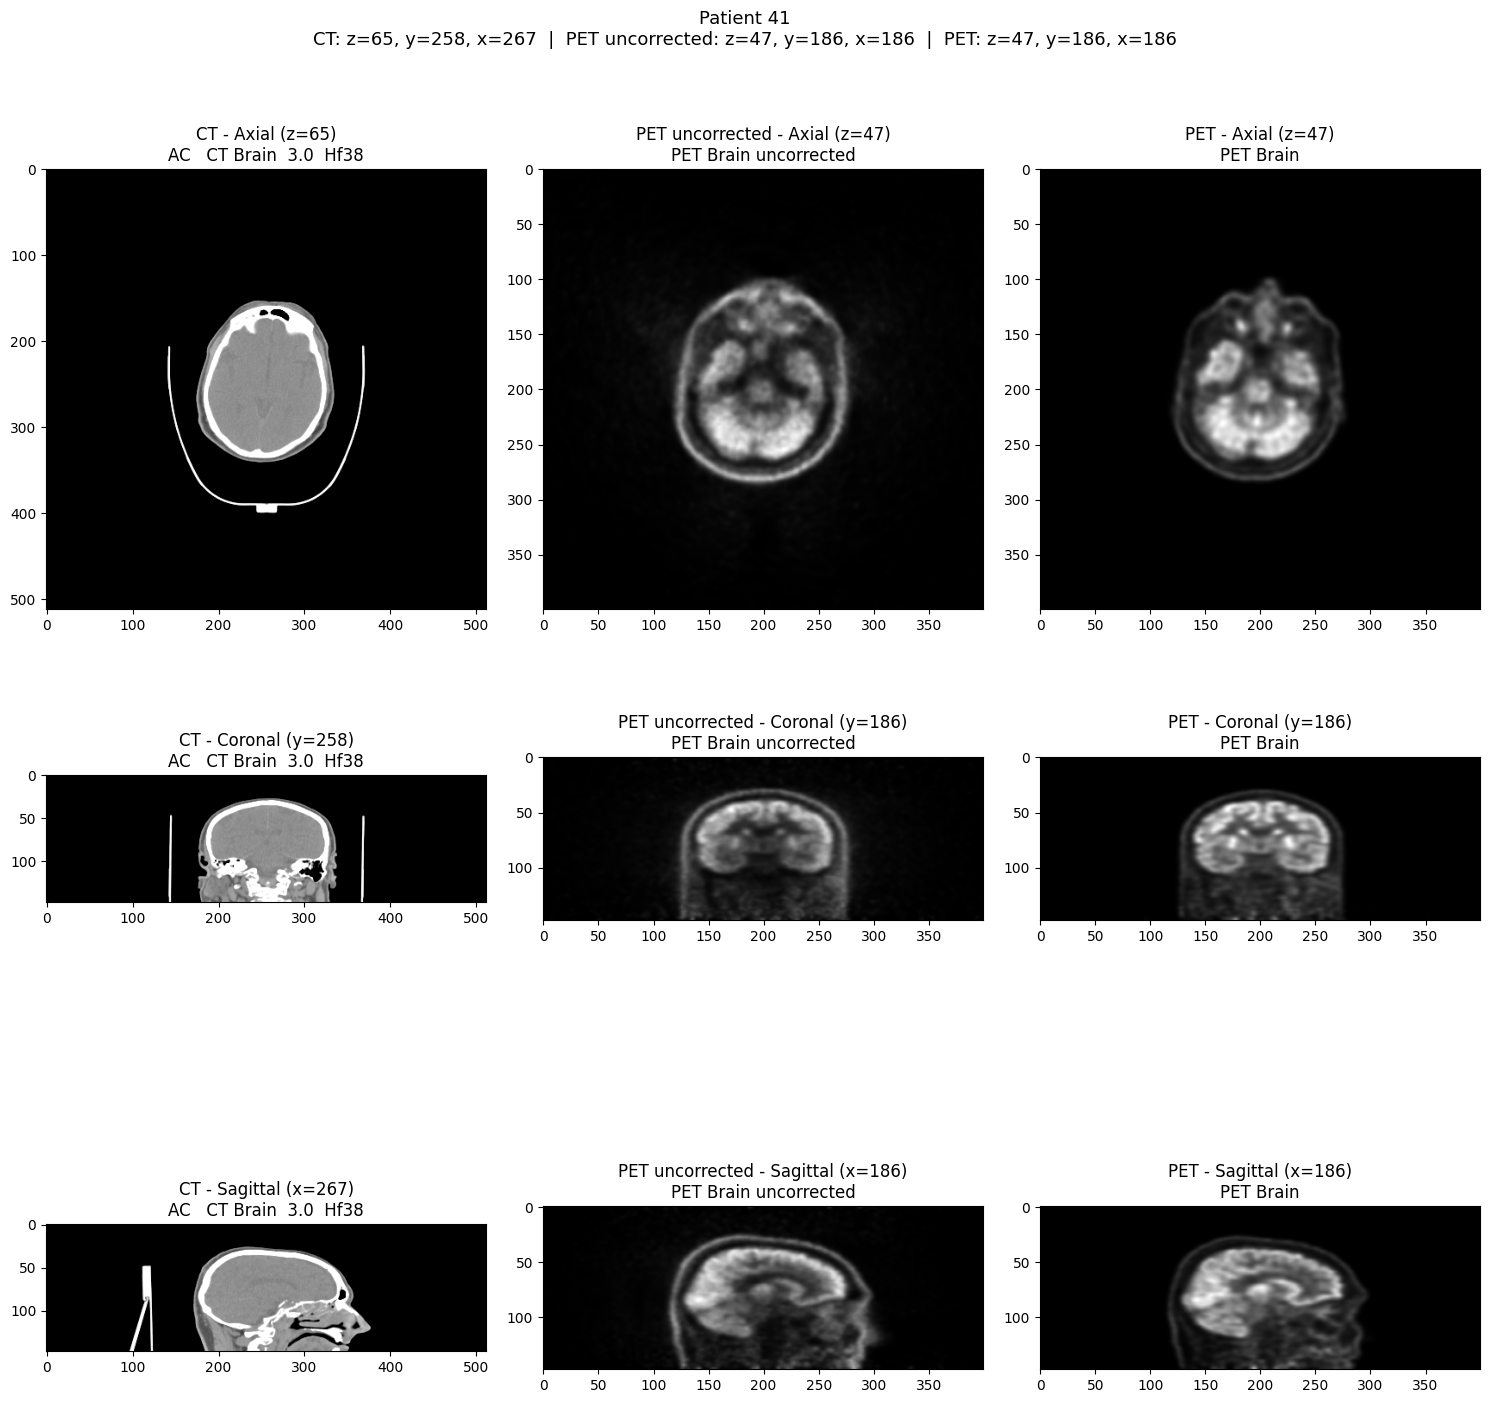

In [ ]:

patient_keys = list(patients.keys()) # sorted list of patient keys for indexing
idx = 40
one_patient_key = patient_keys[idx]
show_one_patient_multiplanar(
    patient_key=one_patient_key,
    patients_sorted=patients,
    series_dict=None,               
    series_files_dict=series,       
    patient_label =f"Patient {idx+1}"             
)
